In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader, Dataset, ConcatDataset
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# Calculo de similaridade
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from scipy.spatial.distance import euclidean
from scipy.spatial.distance import cityblock
from sklearn.metrics import jaccard_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Define seed
SEED = 42

# Set the seed for reproducibility
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups
torch.backends.cudnn.deterministic = True  # Ensure deterministic behavior
torch.backends.cudnn.benchmark = False    # Disable if you want deterministic results

Feature_ambos = [
                #'L4_SRC_PORT',
                #'L4_DST_PORT',
                'PROTOCOL',
                #'L7_PROTO',
                'IN_BYTES',
                'IN_PKTS',
                'OUT_BYTES',
                'OUT_PKTS',
                #'TCP_FLAGS',
                #'CLIENT_TCP_FLAGS',
                #'SERVER_TCP_FLAGS',
                'FLOW_DURATION_MILLISECONDS',
                'DURATION_IN',
                'DURATION_OUT',
                #'MIN_TTL',
                #'MAX_TTL',
                'LONGEST_FLOW_PKT',
                #'SHORTEST_FLOW_PKT',
                #'MIN_IP_PKT_LEN',
                'MAX_IP_PKT_LEN',
                'SRC_TO_DST_SECOND_BYTES',
                'DST_TO_SRC_SECOND_BYTES',
                'RETRANSMITTED_IN_BYTES',
                'RETRANSMITTED_IN_PKTS',
                'RETRANSMITTED_OUT_BYTES',
                'RETRANSMITTED_OUT_PKTS',
                'SRC_TO_DST_AVG_THROUGHPUT',
                'DST_TO_SRC_AVG_THROUGHPUT',
                'NUM_PKTS_UP_TO_128_BYTES',
                'NUM_PKTS_128_TO_256_BYTES',
                'NUM_PKTS_256_TO_512_BYTES',
                'NUM_PKTS_512_TO_1024_BYTES',
                'NUM_PKTS_1024_TO_1514_BYTES',
                #'TCP_WIN_MAX_IN',
                #'TCP_WIN_MAX_OUT',
                'ICMP_TYPE',
                'ICMP_IPV4_TYPE',
                #'DNS_QUERY_ID',
                'DNS_QUERY_TYPE',
                #'DNS_TTL_ANSWER',
                #'FTP_COMMAND_RET_CODE',
                'Label',
                'Attack']

Feature_name = [f for f in Feature_ambos if f not in ['Label', 'Attack']]

input_dim = 26

# Mapear todos os ataques
map_attacks = {'Benign':0,
              'DoS':1,
              'dos':1,
              'Reconnaissance':2,
              'DDoS':3,
              'ddos':3,
              'Theft':4,
              'ransomware':5,
              'scanning':6,
              'xss':7,
              'mitm':8,
              'password':9,
              'Backdoor':10,
              'backdoor':10,
              'Analysis':11,
              'Generic':12,
              'Exploits':13,
              'Bot':14,
              'DoS_attacks-SlowHTTPTest':15,
              'SSH-Bruteforce':16,
              'DoS_attacks-Hulk':17,
              'Infilteration':18,
              'DDOS_attack-HOIC':19,
              'FTP-BruteForce':20,
              'Brute_Force_-Web':21,
              'DDoS_attacks-LOIC-HTTP':22,
              'DoS_attacks-GoldenEye':23,
              'DDOS_attack-LOIC-UDP':24,
              'DoS_attacks-Slowloris':25,
              'Brute_Force_-XSS':26,
              'SQL_Injection':27
              }

In [2]:
class AE(nn.Module):
    def __init__(self, input_dim, latent_dim, dropout_rate=0.1):
        super(AE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 256), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 64), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 64), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 128), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, 256), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 512), nn.PReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        x_enc = self.encoder(x)
        recon = self.decoder(x_enc)
        return recon, x_enc

In [3]:
def ae_loss(recon_x, x):
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    return recon_loss

In [4]:
class MLP(nn.Module):
    def __init__(self, latent_dim):
        super(MLP, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.ReLU(True),
            nn.Dropout(0.2),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.mlp(x)

In [5]:
def get_datasets(dataset):

    if dataset == "dataset1":
         df = pd.read_csv('datasets/dataset1v2.csv') # NF-BoT-IoT-v2
    if dataset == "dataset2":
         df = pd.read_csv('datasets/dataset2v2.csv') # NF-ToN-IoT-v2
    if dataset == "dataset3":
         df = pd.read_csv('datasets/dataset3v2.csv') # NF-UNSW-NB15-v2
    if dataset == "dataset4":
         df = pd.read_csv('datasets/dataset4v2.csv') # NF-CICIDS2018-v3

    dataframe = df[Feature_ambos]

    return dataframe

In [6]:
def preprocessing_data(df):
    df_split = df.copy()
    df_split_label = df_split['Attack']
    df_split = df_split.drop('Attack',axis=1)
    df_split = df_split.drop('Label',axis=1)

    # Inicializando o MinMaxScaler (intervalo padrão é [0, 1])
    scaler = MinMaxScaler()

    # Ajustando e transformando os dados
    df_split = scaler.fit_transform(df_split)

    df_split_label = df_split_label.to_frame()
    x_split_train, x_split_temp, y_split_train, y_split_temp = train_test_split(df_split, df_split_label, test_size = 0.30, stratify=df_split_label)
    x_split_test, x_split_val, y_split_test, y_split_val = train_test_split(x_split_temp, y_split_temp, test_size = 0.50, stratify=y_split_temp)
    y_split_train['Attack'] = y_split_train['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)
    z_split_test = y_split_test.copy()
    y_split_test['Attack'] = y_split_test['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)
    #print(z_split_test)
    z_split_test['Attack']=z_split_test['Attack'].map(map_attacks)
    #z_test = torch.tensor(np.array(z_split_test, dtype=np.float32), dtype = torch.float)
    class_test = torch.tensor(np.array(y_split_test, dtype=np.float32), dtype = torch.float)
    class_attack = torch.tensor(np.array(z_split_test, dtype=np.float32), dtype = torch.float)
    dataset = torch.utils.data.TensorDataset(class_attack, class_test)
    z_test = torch.utils.data.DataLoader(dataset, batch_size=100)
    #print(z_split_test)
    y_split_val['Attack'] = y_split_val['Attack'].apply(lambda x: 0 if x == 'Benign' else 1)
    return x_split_train, y_split_train, x_split_val, y_split_val, x_split_test, y_split_test, z_test

In [7]:
def tensor_data(x_source1_train, y_source1_train):
    previsores_train = torch.tensor(np.array(x_source1_train), dtype = torch.float)
    class_train = torch.tensor(np.array(y_source1_train, dtype=np.float32), dtype = torch.float)
    dataset = torch.utils.data.TensorDataset(previsores_train, class_train)
    train_loader = torch.utils.data.DataLoader(dataset, batch_size=100, shuffle=True)
    return previsores_train, class_train, dataset, train_loader

In [8]:
def inicia_datasets(treino):
      df = get_datasets(treino)
      print(f"Prepara {treino}: {df.shape}")
      x_split_train, y_split_train, x_split_val, y_split_val, x_split_test, y_split_test, z_split_test = preprocessing_data(df)
      print( x_split_train.shape, y_split_train.shape)
      print( x_split_val.shape, y_split_val.shape)
      print( x_split_test.shape, y_split_test.shape)
      dataset_train, class_train, dataset_train, loader_train = tensor_data( x_split_train,  y_split_train)
      dataset_val, class_val, dataset_val, loader_val = tensor_data( x_split_val,  y_split_val)
      dataset_test, class_test, dataset_test, loader_test = tensor_data( x_split_test,  y_split_test)
      return dataset_train, class_train, dataset_train, loader_train, dataset_val, class_val, dataset_val, loader_val, dataset_test, class_test, dataset_test, loader_test, z_split_test

In [9]:
dataset = "dataset1"
dataset_train1, class_train1, dataset_train1, loader_train1, dataset_val1, class_val1, dataset_val1, loader_val1, dataset_test1, class_test1, dataset_test1, loader_test1, z_split_test1 = inicia_datasets(dataset)
dataset = "dataset2"
dataset_train2, class_train2, dataset_train2, loader_train2, dataset_val2, class_val2, dataset_val2, loader_val2, dataset_test2, class_test2, dataset_test2, loader_test2, z_split_test2 = inicia_datasets(dataset)
dataset = "dataset3"
dataset_train3, class_train3, dataset_train3, loader_train3, dataset_val3, class_val3, dataset_val3, loader_val3, dataset_test3, class_test3, dataset_test3, loader_test3, z_split_test3 = inicia_datasets(dataset)
dataset = "dataset4"
dataset_train4, class_train4, dataset_train4, loader_train4, dataset_val4, class_val4, dataset_val4, loader_val4, dataset_test4, class_test4, dataset_test4, loader_test4, z_split_test4 = inicia_datasets(dataset)

# Gerar ambos para teste e validação
test_dataset_combined = ConcatDataset([dataset_test1, dataset_test2, dataset_test3, dataset_test4])
test_loader_combined = DataLoader(test_dataset_combined, batch_size=loader_test1.batch_size, shuffle=True)
val_dataset_combined = ConcatDataset([dataset_val1, dataset_val2, dataset_val3, dataset_val4])
val_loader_combined = DataLoader(val_dataset_combined, batch_size=loader_val1.batch_size, shuffle=True)

Prepara dataset1: (224511, 28)
(157157, 26) (157157, 1)
(33677, 26) (33677, 1)
(33677, 26) (33677, 1)
Prepara dataset2: (224512, 28)
(157158, 26) (157158, 1)
(33677, 26) (33677, 1)
(33677, 26) (33677, 1)
Prepara dataset3: (142152, 28)
(99506, 26) (99506, 1)
(21323, 26) (21323, 1)
(21323, 26) (21323, 1)
Prepara dataset4: (223976, 28)
(156783, 26) (156783, 1)
(33597, 26) (33597, 1)
(33596, 26) (33596, 1)


In [10]:
def treina_modelo(modelo_AE1, modelo_MLP, input_dim, device):

    from sklearn.metrics import classification_report

    # Hiperparâmetros
    num_classes = 2
    epochs = 600
    lr = 0.001

    Alpha = 1.0
    Beta = 1.0

    patience = 50
    best_val_acc = 0
    epochs_no_improve = 0
    best_model_state = None

    # Otimizador conjunto
    params = list(modelo_MLP.parameters()) + list(modelo_AE1.parameters())
    optimizer = torch.optim.Adam(params, lr=lr)

    # Scheduler: reduz o learning rate se a acurácia parar de melhorar
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=10, factor=0.5)

    # Funções de perda
    class_loss_fn = nn.BCEWithLogitsLoss()

    # Histórico
    loss_vals = []
    loss_valsAE = []
    loss_valsAE2 = []
    loss_valsMLP = []
    val_simC = []
    val_distE = []
    val_distM = []
    val_accuracies = []
    val_losses = []


    for epoch in range(epochs):

        modelo_AE1.train()
        modelo_MLP.train()

        sum_loss_recon = 0.0
        sum_loss_class = 0.0
        n_batches = 0
        epoch_loss_val = []
        epoch_simC = []
        epoch_corr = []
        epoch_distE = []
        epoch_distM = []
        epoch_simJ = []

        # Variaveis para similaridade
        simC = 0  # Cosseno
        corr = 0  # Pearson 1.0 Correlação perfeita
        distE = 0  #  Eculidiana - Distância euclidiana
        distM = 0  # Distância de Manhattan
        simJ = 0  # Similaridade de Jaccard (para vetores binários ou conjuntos)

        for (X1, y1), (X2, y2), (X3, y3), (X4, y4) in zip(loader_train1, loader_train2, loader_train3, loader_train4):

            X = torch.cat([X1, X2, X3, X4], dim=0).to(device)
            y = torch.cat([y1, y2, y3, y4], dim=0).to(device).float()
            y = y.view(-1, 1)

            optimizer.zero_grad()

            # Forward do VAE1
            recon1, x_latent1 = modelo_AE1(X)

            # Perda de reconstrução (VAE1)
            recon_loss1 = ae_loss(recon1, X)

            # Classificação com vetor latente
            outputs = modelo_MLP(x_latent1)
            loss_class = F.binary_cross_entropy(outputs, y)

            total_loss =  ( recon_loss1 * Alpha ) + ( loss_class * Beta )

            total_loss.backward()
            optimizer.step()

            sum_loss_recon += recon_loss1.item()
            sum_loss_class += loss_class.item()
            n_batches += 1

            torch.cuda.empty_cache()

        # === Logs da época ===
        loss_epoch_recon = sum_loss_recon / n_batches
        loss_epoch_class = sum_loss_class / n_batches

        loss_valsAE.append(loss_epoch_recon)
        loss_valsMLP.append(loss_epoch_class)

        print(f"Epoch {epoch+1:02d}/{epochs} | Recon: {loss_epoch_recon:.4f} | Class: {loss_epoch_class:.4f}")
        # Mostrar a simialridade da útlima instancia por época
        #print(f"Similaridade Média mu1, mu2 - Cosseno: {np.mean(simC)} | Euclidiana: {distE} | Manhattan: {distM}")
        modelo_AE1.eval()
        modelo_MLP.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():

           for (X1, y1), (X2, y2), (X3, y3), (X4, y4) in zip(loader_val1, loader_val2, loader_val3, loader_val4):

               X = torch.cat([X1, X2, X3, X4], dim=0).to(device)
               y = torch.cat([y1, y2, y3, y4], dim=0).to(device).float()
               y = y.view(-1, 1)

               optimizer.zero_grad()

               # Forward do VAE1, VAE2 e VAE3
               recon1, x_latent1 = modelo_AE1(X)

               # Classificação com vetor latente
               outputs = modelo_MLP(x_latent1)
               loss_class = F.binary_cross_entropy(outputs, y)

               preds = (outputs > 0.5).float()

               # Calcula loss (BCE para binário)
               loss = F.binary_cross_entropy(outputs, y)

               epoch_loss_val.append(loss.item())

               all_preds.append(preds.cpu())
               all_labels.append(y.cpu())

        all_preds_list = torch.cat(all_preds)
        all_labels_list = torch.cat(all_labels)
        acc = (all_preds_list.view(-1) == all_labels_list.view(-1)).float().mean().item()
        loss_val = sum(epoch_loss_val) / len(epoch_loss_val)

        val_accuracies.append(acc)
        val_losses.append(loss_val)
        print(f"Acurácia: {acc}")

        # Atualiza scheduler com base na acurácia de validação
        scheduler.step(acc)

        # Mostra o learning rate atual
        for param_group in optimizer.param_groups:
            current_lr = param_group['lr']
        print(f"Learning Rate atual: {current_lr:.6f}")

        # Early stopping
        if acc > best_val_acc:
            best_val_acc = acc
            epochs_no_improve = 0
            best_model_state = modelo_MLP.state_dict()
        else:
            epochs_no_improve += 1
            print(f"Sem melhoria na validação por {epochs_no_improve} época(s).")
            if epochs_no_improve >= patience:
                print(f"Early stopping ativado na época {epoch+1}")
                break

    # Restaurar melhor modelo
    if best_model_state is not None:
        modelo_MLP.load_state_dict(best_model_state)
        print("Melhor modelo MLP restaurado com base na menor perda de validação.")

    return  all_preds, all_labels

In [12]:
# Instanciando o modelo
latent_dim = 16
modelo_AE1 = AE(input_dim, latent_dim)
modelo_MLP = MLP(latent_dim)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [13]:
import time

start = time.time()
train_preds, train_labels = treina_modelo(modelo_AE1, modelo_MLP, input_dim, device)
end = time.time()
tempo = end - start
print("Tempo de execução: ", tempo)

import psutil
import os

process = psutil.Process(os.getpid())
print("Memória usada (MB):", process.memory_info().rss / 1024**2)

Epoch 01/600 | Recon: 22.6519 | Class: 0.6036
Acurácia: 0.6812787055969238
Learning Rate atual: 0.001000
Epoch 02/600 | Recon: 5.8099 | Class: 0.5625
Acurácia: 0.6880488395690918
Learning Rate atual: 0.001000
Epoch 03/600 | Recon: 4.4260 | Class: 0.5429
Acurácia: 0.7290670275688171
Learning Rate atual: 0.001000
Epoch 04/600 | Recon: 3.7360 | Class: 0.5250
Acurácia: 0.7421044707298279
Learning Rate atual: 0.001000
Epoch 05/600 | Recon: 3.5022 | Class: 0.5144
Acurácia: 0.7489446997642517
Learning Rate atual: 0.001000
Epoch 06/600 | Recon: 3.1180 | Class: 0.5067
Acurácia: 0.7458929419517517
Learning Rate atual: 0.001000
Sem melhoria na validação por 1 época(s).
Epoch 07/600 | Recon: 2.9426 | Class: 0.4992
Acurácia: 0.7544286251068115
Learning Rate atual: 0.001000
Epoch 08/600 | Recon: 2.7918 | Class: 0.4946
Acurácia: 0.7475181818008423
Learning Rate atual: 0.001000
Sem melhoria na validação por 1 época(s).
Epoch 09/600 | Recon: 2.6733 | Class: 0.4905
Acurácia: 0.7768670320510864
Learning 

Epoch 65/600 | Recon: 1.5386 | Class: 0.3575
Acurácia: 0.856073796749115
Learning Rate atual: 0.001000
Sem melhoria na validação por 5 época(s).
Epoch 66/600 | Recon: 1.4721 | Class: 0.3531
Acurácia: 0.8547875881195068
Learning Rate atual: 0.001000
Sem melhoria na validação por 6 época(s).
Epoch 67/600 | Recon: 1.5323 | Class: 0.3565
Acurácia: 0.8545186519622803
Learning Rate atual: 0.001000
Sem melhoria na validação por 7 época(s).
Epoch 68/600 | Recon: 1.6092 | Class: 0.3578
Acurácia: 0.8537118434906006
Learning Rate atual: 0.001000
Sem melhoria na validação por 8 época(s).
Epoch 69/600 | Recon: 1.4781 | Class: 0.3524
Acurácia: 0.8488243222236633
Learning Rate atual: 0.001000
Sem melhoria na validação por 9 época(s).
Epoch 70/600 | Recon: 1.5688 | Class: 0.3576
Acurácia: 0.862645149230957
Learning Rate atual: 0.001000
Epoch 71/600 | Recon: 1.5106 | Class: 0.3505
Acurácia: 0.8661646842956543
Learning Rate atual: 0.001000
Epoch 72/600 | Recon: 1.6304 | Class: 0.3636
Acurácia: 0.8602598

Acurácia: 0.8722448945045471
Learning Rate atual: 0.000500
Sem melhoria na validação por 2 época(s).
Epoch 124/600 | Recon: 1.1556 | Class: 0.3175
Acurácia: 0.8814003467559814
Learning Rate atual: 0.000500
Epoch 125/600 | Recon: 1.1603 | Class: 0.3168
Acurácia: 0.8764426112174988
Learning Rate atual: 0.000500
Sem melhoria na validação por 1 época(s).
Epoch 126/600 | Recon: 1.1316 | Class: 0.3143
Acurácia: 0.8786993026733398
Learning Rate atual: 0.000500
Sem melhoria na validação por 2 época(s).
Epoch 127/600 | Recon: 1.1221 | Class: 0.3142
Acurácia: 0.8801959753036499
Learning Rate atual: 0.000500
Sem melhoria na validação por 3 época(s).
Epoch 128/600 | Recon: 1.1161 | Class: 0.3144
Acurácia: 0.8778106570243835
Learning Rate atual: 0.000500
Sem melhoria na validação por 4 época(s).
Epoch 129/600 | Recon: 1.1698 | Class: 0.3160
Acurácia: 0.8725138306617737
Learning Rate atual: 0.000500
Sem melhoria na validação por 5 época(s).
Epoch 130/600 | Recon: 1.1401 | Class: 0.3100
Acurácia: 0.8

Epoch 183/600 | Recon: 0.9241 | Class: 0.2905
Acurácia: 0.8863229751586914
Learning Rate atual: 0.000250
Sem melhoria na validação por 2 época(s).
Epoch 184/600 | Recon: 0.9184 | Class: 0.2884
Acurácia: 0.8921810388565063
Learning Rate atual: 0.000250
Epoch 185/600 | Recon: 0.9111 | Class: 0.2891
Acurácia: 0.8928475379943848
Learning Rate atual: 0.000250
Epoch 186/600 | Recon: 0.9327 | Class: 0.2889
Acurácia: 0.8906142115592957
Learning Rate atual: 0.000250
Sem melhoria na validação por 1 época(s).
Epoch 187/600 | Recon: 0.9209 | Class: 0.2884
Acurácia: 0.8915145397186279
Learning Rate atual: 0.000250
Sem melhoria na validação por 2 época(s).
Epoch 188/600 | Recon: 0.9119 | Class: 0.2876
Acurácia: 0.894858717918396
Learning Rate atual: 0.000250
Epoch 189/600 | Recon: 0.9643 | Class: 0.2897
Acurácia: 0.8919355273246765
Learning Rate atual: 0.000250
Sem melhoria na validação por 1 época(s).
Epoch 190/600 | Recon: 0.8973 | Class: 0.2867
Acurácia: 0.8927305936813354
Learning Rate atual: 0.

Epoch 243/600 | Recon: 0.8122 | Class: 0.2666
Acurácia: 0.9047975540161133
Learning Rate atual: 0.000063
Sem melhoria na validação por 13 época(s).
Epoch 244/600 | Recon: 0.8078 | Class: 0.2670
Acurácia: 0.9036750197410583
Learning Rate atual: 0.000063
Sem melhoria na validação por 14 época(s).
Epoch 245/600 | Recon: 0.8081 | Class: 0.2666
Acurácia: 0.9062708020210266
Learning Rate atual: 0.000063
Sem melhoria na validação por 15 época(s).
Epoch 246/600 | Recon: 0.8081 | Class: 0.2669
Acurácia: 0.9009622931480408
Learning Rate atual: 0.000063
Sem melhoria na validação por 16 época(s).
Epoch 247/600 | Recon: 0.8187 | Class: 0.2654
Acurácia: 0.9047390818595886
Learning Rate atual: 0.000063
Sem melhoria na validação por 17 época(s).
Epoch 248/600 | Recon: 0.8213 | Class: 0.2651
Acurácia: 0.8992201089859009
Learning Rate atual: 0.000063
Sem melhoria na validação por 18 época(s).
Epoch 249/600 | Recon: 0.8099 | Class: 0.2656
Acurácia: 0.8994773626327515
Learning Rate atual: 0.000063
Sem mel

Epoch 301/600 | Recon: 0.7816 | Class: 0.2602
Acurácia: 0.9034177660942078
Learning Rate atual: 0.000008
Sem melhoria na validação por 23 época(s).
Epoch 302/600 | Recon: 0.7780 | Class: 0.2608
Acurácia: 0.903148889541626
Learning Rate atual: 0.000008
Sem melhoria na validação por 24 época(s).
Epoch 303/600 | Recon: 0.7808 | Class: 0.2614
Acurácia: 0.9031254649162292
Learning Rate atual: 0.000008
Sem melhoria na validação por 25 época(s).
Epoch 304/600 | Recon: 0.7748 | Class: 0.2592
Acurácia: 0.9033710360527039
Learning Rate atual: 0.000008
Sem melhoria na validação por 26 época(s).
Epoch 305/600 | Recon: 0.7790 | Class: 0.2585
Acurácia: 0.9021081924438477
Learning Rate atual: 0.000008
Sem melhoria na validação por 27 época(s).
Epoch 306/600 | Recon: 0.7815 | Class: 0.2593
Acurácia: 0.9038854837417603
Learning Rate atual: 0.000008
Sem melhoria na validação por 28 época(s).
Epoch 307/600 | Recon: 0.7746 | Class: 0.2595
Acurácia: 0.9044467806816101
Learning Rate atual: 0.000008
Sem melh

Acurácia: 0.9027746915817261
Learning Rate atual: 0.000000
Sem melhoria na validação por 4 época(s).
Epoch 358/600 | Recon: 0.7704 | Class: 0.2601
Acurácia: 0.9030904173851013
Learning Rate atual: 0.000000
Sem melhoria na validação por 5 época(s).
Epoch 359/600 | Recon: 0.7797 | Class: 0.2600
Acurácia: 0.9024707078933716
Learning Rate atual: 0.000000
Sem melhoria na validação por 6 época(s).
Epoch 360/600 | Recon: 0.7784 | Class: 0.2588
Acurácia: 0.9037802815437317
Learning Rate atual: 0.000000
Sem melhoria na validação por 7 época(s).
Epoch 361/600 | Recon: 0.7788 | Class: 0.2591
Acurácia: 0.9032424092292786
Learning Rate atual: 0.000000
Sem melhoria na validação por 8 época(s).
Epoch 362/600 | Recon: 0.7758 | Class: 0.2600
Acurácia: 0.9033242464065552
Learning Rate atual: 0.000000
Sem melhoria na validação por 9 época(s).
Epoch 363/600 | Recon: 0.7645 | Class: 0.2602
Acurácia: 0.9041895270347595
Learning Rate atual: 0.000000
Sem melhoria na validação por 10 época(s).
Epoch 364/600 | 

In [14]:
def testa(target_test, treino, labels_test):
  # Valida source
  modelo_AE1.eval()
  modelo_MLP.eval()
  all_preds, all_labels, all_attacks = [], [], []

  with torch.no_grad():

    for (X, y), (z, y2) in zip(target_test, labels_test):

         X = X.to(device)
         y = y.to(device).float()
         y = y.view(-1, 1)
         z = z.to(device).float()
         z = z.view(-1, 1)

         # Forward do VAE1, VAE2
         recon1, x_latent1 = modelo_AE1(X)

         # Classificação com vetor latente
         outputs = modelo_MLP(x_latent1)
         loss_class = F.binary_cross_entropy(outputs, y)

         preds = (outputs > 0.5).float()

         # Calcula loss (BCE para binário)
         loss = F.binary_cross_entropy(outputs, y)

         all_preds.append(preds.cpu())
         all_labels.append(y.cpu())
         all_attacks.append(z.cpu())

  all_preds_list = torch.cat(all_preds)
  all_labels_list = torch.cat(all_labels)
  all_attacks_list = torch.cat(all_attacks)

  acc = (all_preds_list.view(-1) == all_labels_list.view(-1)).float().mean().item()

  # Matriz de confusão
  matriz2 = confusion_matrix(all_preds_list.numpy().round(), all_labels_list.numpy().round())
  sns.set(rc={"figure.figsize": (6, 6)})
  title = "Matriz de Confusão: " + treino
  sns.heatmap(matriz2/np.sum(matriz2), annot=True, annot_kws={'size': 10}, fmt='.2%', cmap='Blues').set_title(title)
  plt.show()

  # Extração dos elementos da matriz (para problema binário)
  TN, FP, FN, TP = matriz2.ravel()

  # Cálculo das métricas
  TPR = TP / (TP + FN) if (TP + FN) != 0 else 0  # Sensibilidade, Recall
  TNR = TN / (TN + FP) if (TN + FP) != 0 else 0  # Especificidade
  F1 = f1_score(all_labels_list.detach().numpy().round(), all_preds_list.detach().numpy().round())
  return TPR, TNR, F1, acc, all_preds_list.view(-1), all_labels_list.view(-1), all_attacks_list.view(-1)

Treinando com Ambos e validando com dataset1


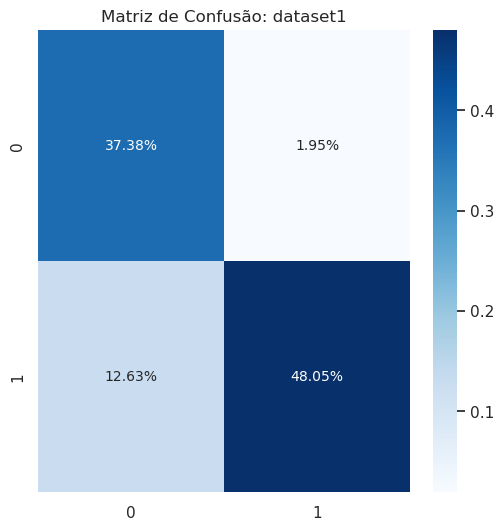

Treinando com Ambos e validando com dataset2


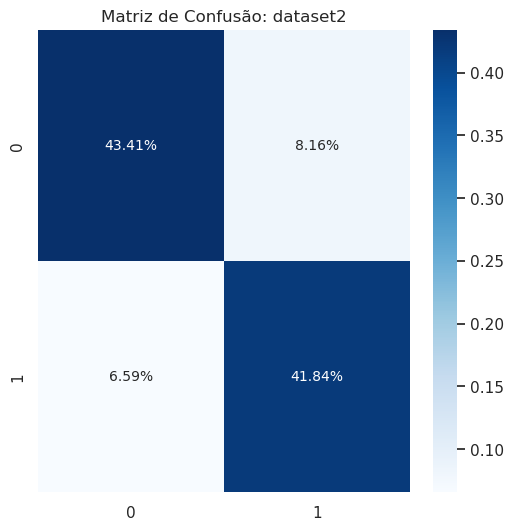

Treinando com Ambos e validando com dataset3


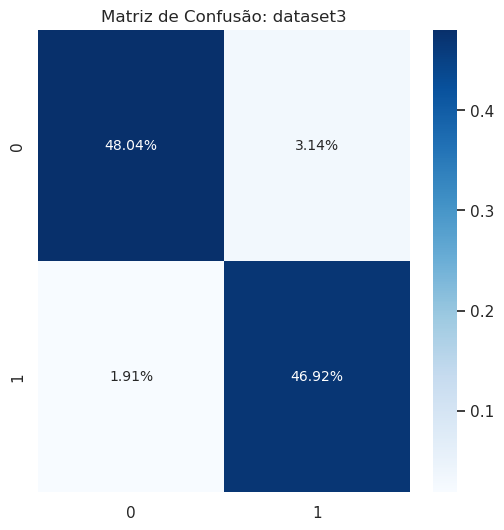

Treinando com Ambos e validando com dataset4


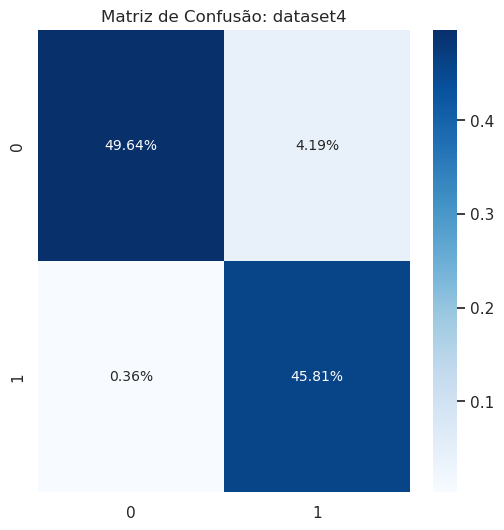

----------------------------------------------
Resumo da validação nos Datasets:
    Dataset       TPR       TNR  F1-Score  Acurácia
0  dataset1  0.791905  0.950393  0.868289  0.854233
1  dataset2  0.863887  0.841711  0.850101  0.852451
2  dataset3  0.960907  0.938691  0.948966  0.949538
3  dataset4  0.992264  0.922201  0.952738  0.954548
----------------------------------------------


In [15]:
datasets = ["dataset1", "dataset2", "dataset3", "dataset4"]
target_test = [loader_test1, loader_test2, loader_test3, loader_test4]
labels_test = [z_split_test1, z_split_test2, z_split_test3, z_split_test4]

TPRs = []
TNRs = []
F1s = []
ACCs = []
all_preds_lists = []
all_labels_lists = []
all_attacks_lists = []

for data, teste, labels  in zip(datasets, target_test, labels_test):
    print(f"Treinando com Ambos e validando com {data}")
    TPR, TNR, F1, acc, all_preds_list, all_labels_list, all_attacks_list = testa(teste, data, labels)
    TPRs.append(TPR)
    TNRs.append(TNR)
    F1s.append(F1)
    ACCs.append(acc)
    all_preds_lists.extend(all_preds_list)
    all_labels_lists.extend(all_labels_list)
    all_attacks_lists.extend(all_attacks_list)

# Criação da tabela
df = pd.DataFrame({
    'Dataset': datasets,
    'TPR': TPRs,
    'TNR': TNRs,
    'F1-Score': F1s,
    'Acurácia': ACCs
})
print("----------------------------------------------")
print("Resumo da validação nos Datasets:")
print(df)
print("----------------------------------------------")

In [16]:
# Combinar todas as predições em um dataframe para tabulação

all_labels = [t.item() for t in all_labels_lists]
all_preds = [t.item() for t in all_preds_lists]
all_attacks = [t.item() for t in all_attacks_lists]

# Inverter dicionario
map_attacks_inv = {v: k for k, v in map_attacks.items()}

df = pd.DataFrame({
    "Real": all_labels,
    "Previsto": all_preds,
    "Ataque": all_attacks
})

# Criar coluna de acerto/erro
df["Acertou"] = df["Real"] == df["Previsto"]

# Agrupar predições por tipo de ataque
tabela = df.groupby("Ataque").agg(
    Total=("Real","count"),
    Acertos=("Acertou","sum")
)

# Adicionar Acurácia por ataque
tabela["Acurácia"] = tabela["Acertos"] / tabela["Total"]

# Adicionar F1 por ataque
f1_por_ataque = {}
TP_por_ataque = {}
TN_por_ataque = {}
FP_por_ataque = {}
FN_por_ataque = {}
for atk, grupo in df.groupby("Ataque"):
    f1_por_ataque[atk] = f1_score(grupo["Real"], grupo["Previsto"], zero_division=0)
    TP_por_ataque[atk] = ((grupo["Real"] == 1) & (grupo["Previsto"] == 1)).sum()
    TN_por_ataque[atk] = ((grupo["Real"] == 0) & (grupo["Previsto"] == 0)).sum()
    FP_por_ataque[atk] = ((grupo["Real"] == 0) & (grupo["Previsto"] == 1)).sum()
    FN_por_ataque[atk] = ((grupo["Real"] == 1) & (grupo["Previsto"] == 0)).sum()

tabela["TP"] = tabela.index.map(TP_por_ataque)
tabela["TN"] = tabela.index.map(TN_por_ataque)
tabela["FP"] = tabela.index.map(FP_por_ataque)
tabela["FN"] = tabela.index.map(FN_por_ataque)
tabela["F1"] = tabela.index.map(f1_por_ataque)


# Renomear indice pelo nome do ataque
tabela.index = tabela.index.map(map_attacks_inv)

print("Resumo por tipo de ataque:")
print(tabela)

Resumo por tipo de ataque:
                          Total  Acertos  Acurácia     TP     TN    FP    FN  \
Ataque                                                                         
Benign                    61125    54908  0.898290  27739  27169  3486  2731   
dos                        8527     7340  0.860795   3928   3412   898   289   
Reconnaissance             7409     6518  0.879741   3494   3024   720   171   
ddos                       9825     8375  0.852417   4539   3836   996   454   
Theft                       364      312  0.857143    178    134    45     7   
ransomware                  514      436  0.848249    208    228    32    46   
scanning                   2166     1858  0.857802    943    915   130   178   
xss                        2167     1840  0.849100    872    968   135   192   
mitm                       1158      982  0.848014    484    498    74   102   
password                   2167     1866  0.861098    935    931   116   185   
backdoor     